<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Unidad4/Practica_2_Clustering_de_Frutas_con_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
frutas= pd.read_csv("fruit_data_with_colors.csv")
frutas.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [2]:
features = ['mass', 'width', 'height', 'color_score']
x = frutas[features]
x.head()

,mass,width,height,color_score
0,192,8.4,7.3,0.55
1,180,8.0,6.8,0.59
2,176,7.4,7.2,0.60
3,86,6.2,4.7,0.80
4,84,6.0,4.6,0.79


In [3]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

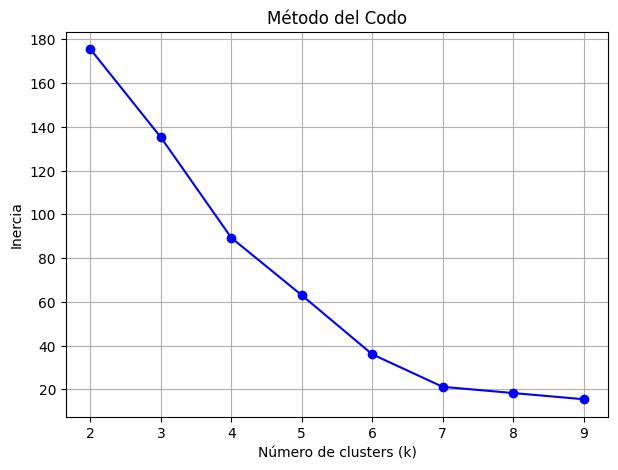

In [4]:
#Metodo codo
from sklearn.cluster import KMeans
inertias = []
K = range(2,10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(7,5))
plt.plot(K, inertias,"bo-")
plt.title("Método del Codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [5]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
frutas["cluster"] = clusters
print("\nDistribución de frutas antes de PCA:")
print(frutas.groupby("fruit_name").size())
print("\nDistribución de frutas por cluster:")
print(frutas.groupby("cluster").size())


Distribución de frutas antes de PCA:
fruit_name
apple       19
lemon       16
mandarin     5
orange      19
dtype: int64

Distribución de frutas por cluster:
cluster
0    22
1    19
2     5
3    13
dtype: int64


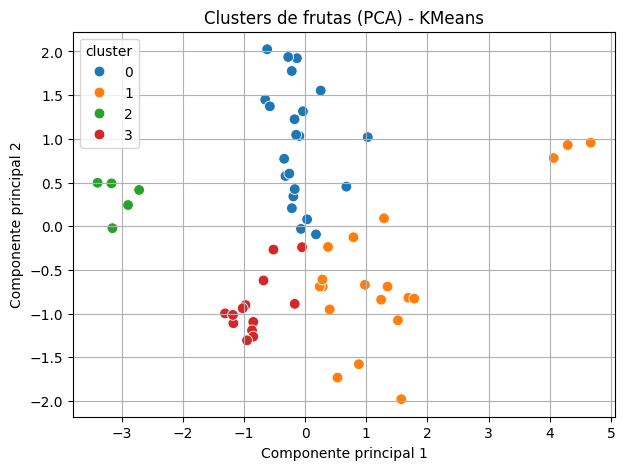

In [6]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_scaled)
frutas["pca1"] = pca_result[:,0]
frutas["pca2"] = pca_result[:,1]
plt.figure(figsize=(7,5))
sns.scatterplot(data=frutas, x="pca1", y="pca2", hue="cluster", palette="tab10", s=60)
plt.title("Clusters de frutas (PCA) - KMeans")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()

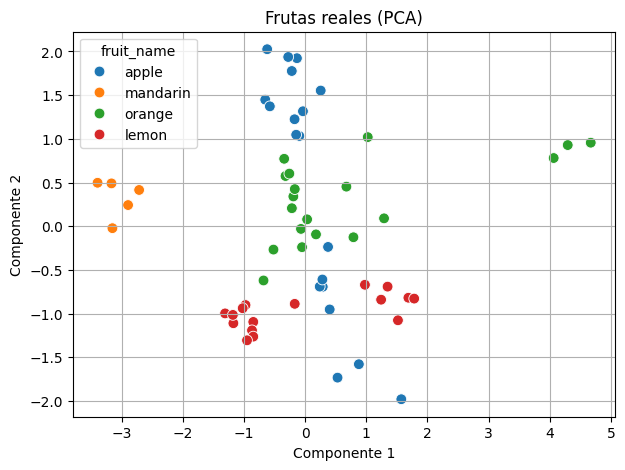

In [7]:
plt.figure(figsize=(7,5))
sns.scatterplot(
x=frutas["pca1"],
y=frutas["pca2"],
hue=frutas["fruit_name"],
palette="tab10",
s=60
)
plt.title("Frutas reales (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

In [8]:
# --- Análisis descriptivo de cada clúster ---
resumen = frutas.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", resumen)


Promedios por clúster:
            mass  width  height  color_score
cluster                                    
0        163.00   7.29    7.47         0.83
1        208.63   7.78    8.61         0.70
2         81.20   5.94    4.38         0.80
3        128.31   6.25    8.01         0.72


In [9]:
kmeans_original = KMeans(n_clusters=4, random_state=42)
clusters_original = kmeans_original.fit_predict(x_scaled)
frutas["cluster_original"] = clusters_original

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)
print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)
# K-Means después del PCA
kmeans_pca = KMeans(n_clusters=4, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)
frutas["cluster_pca"] = clusters_pca

Varianza explicada por PC1 y PC2: [0.57845054 0.25650171]


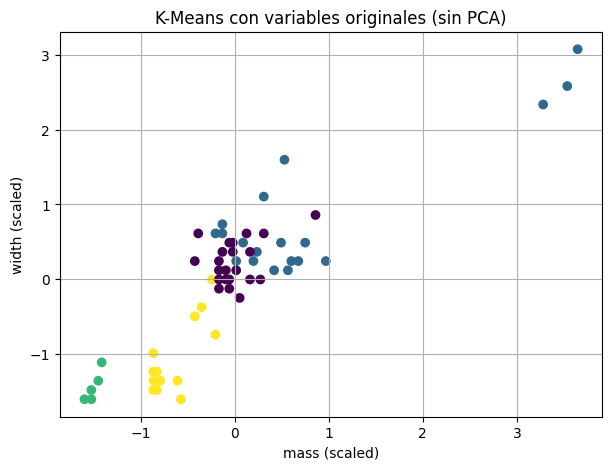

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=clusters_original, cmap='viridis')
plt.xlabel("mass (scaled)")
plt.ylabel("width (scaled)")
plt.title("K-Means con variables originales (sin PCA)")
plt.grid(True)
plt.show()

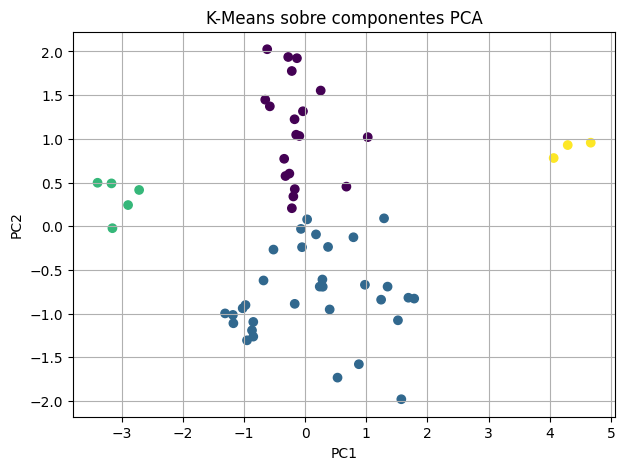

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means sobre componentes PCA")
plt.grid(True)
plt.show()

In [13]:
frutas.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score,cluster,pca1,pca2,cluster_original,cluster_pca
0,1,apple,granny_smith,192,8.4,7.3,0.55,1,1.572169,-1.980044,1,1
1,1,apple,granny_smith,180,8.0,6.8,0.59,1,0.878417,-1.579373,1,1
2,1,apple,granny_smith,176,7.4,7.2,0.60,1,0.529773,-1.732891,1,1
3,2,mandarin,mandarin,86,6.2,4.7,0.80,2,-2.712610,0.414674,2,2
4,2,mandarin,mandarin,84,6.0,4.6,0.79,2,-2.893412,0.242003,2,2


In [14]:
pd.crosstab(frutas["cluster_original"], frutas["cluster_pca"])

cluster_pca,0,1,2,3
cluster_original,,,,
0,19,3,0,0
1,0,16,0,3
2,0,0,5,0
3,0,13,0,0


In [16]:
from sklearn.metrics import silhouette_score
score_original = silhouette_score(x_scaled, clusters_original)
score_pca = silhouette_score(X_pca, clusters_pca)
print("Silueta sin PCA: ", score_original)
print("Silueta con PCA: ", score_pca)

Silueta sin PCA:  0.39419522739862123
Silueta con PCA:  0.4858531414482384


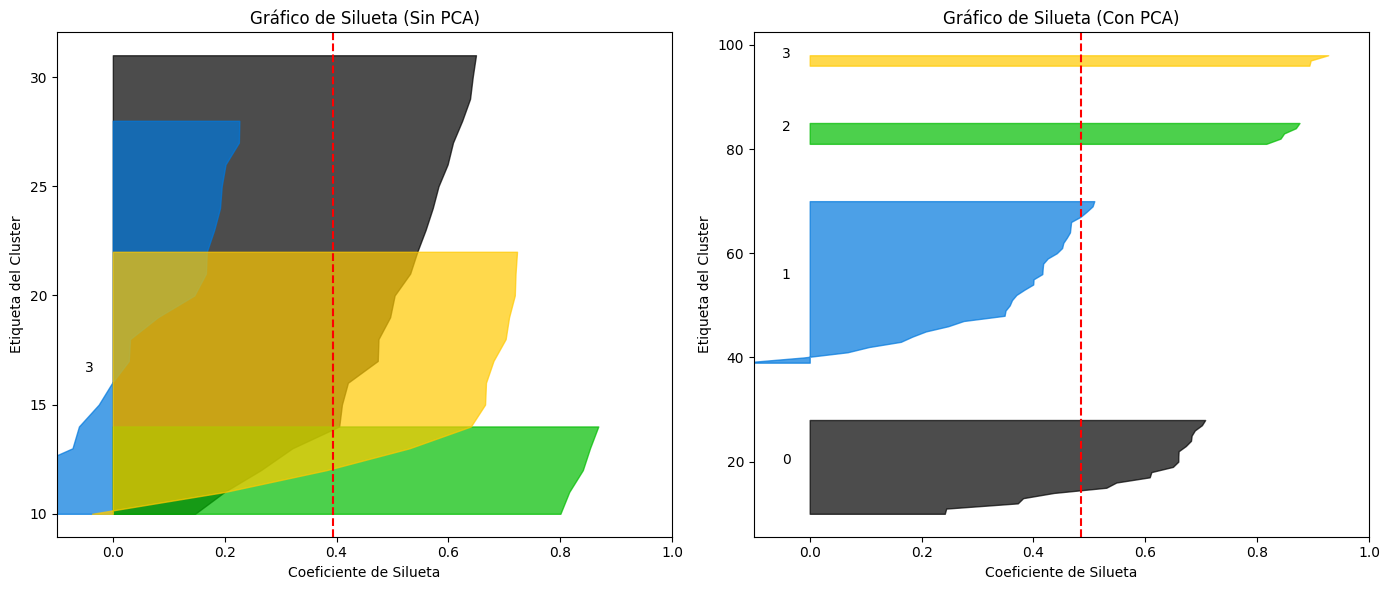

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples
# Calcula valores de silueta para cada muestra
silhouette_vals_original = silhouette_samples(x_scaled, clusters_original)
silhouette_vals_pca = silhouette_samples(X_pca, clusters_pca)
# Número de clusty_lower = 10 for i in range (n_clusters_original):
n_clusters_original =len(np.unique(clusters_original))
n_clusters_pca =len(np.unique(clusters_pca))
fig, axes = plt.subplots(1,2, figsize=(14,6))
# --- Gráfico sin PCA ---
y_lower = 10
for i in range (n_clusters_original):
  ith_cluster_silhouette_values = silhouette_vals_original[clusters_original == i]
  ith_cluster_silhouette_values.sort()
  size_cluster_i = ith_cluster_silhouette_values.shape[0]
  y_upper = y_lower + size_cluster_i
  color = plt.cm.nipy_spectral(float(i) / n_clusters_original)
  axes[0].fill_betweenx(np.arange(y_lower, y_upper),0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
axes[0].text(-0.05, y_lower +0.5* size_cluster_i,str(i))
y_lower = y_upper +10
axes[0].axvline(x=np.mean(silhouette_vals_original), color="red", linestyle="--")
axes[0].set_title("Gráfico de Silueta (Sin PCA)")
axes[0].set_xlabel("Coeficiente de Silueta")
axes[0].set_ylabel("Etiqueta del Cluster")
axes[0].set_xlim([-0.1,1])
# --- Gráfico con PCA ---
y_lower = 10
for i in range (n_clusters_pca):
  ith_cluster_silhouette_values = silhouette_vals_pca[clusters_pca == i]
  ith_cluster_silhouette_values.sort()
  size_cluster_i = ith_cluster_silhouette_values.shape[0]
  y_upper = y_lower + size_cluster_i
  color = plt.cm.nipy_spectral(float(i) / n_clusters_pca)
  axes[1].fill_betweenx(np.arange(y_lower, y_upper),0
                        , ith_cluster_silhouette_values,facecolor=color, edgecolor=color, alpha=0.7)
  axes[1].text(-0.05, y_lower +0.5* size_cluster_i,str(i))
  y_lower = y_upper +10
axes[1].axvline(x=np.mean(silhouette_vals_pca), color="red", linestyle="--")
axes[1].set_title("Gráfico de Silueta (Con PCA)")
axes[1].set_xlabel("Coeficiente de Silueta")
axes[1].set_ylabel("Etiqueta del Cluster")
axes[1].set_xlim([-0.1,1])
plt.tight_layout()
plt.show()

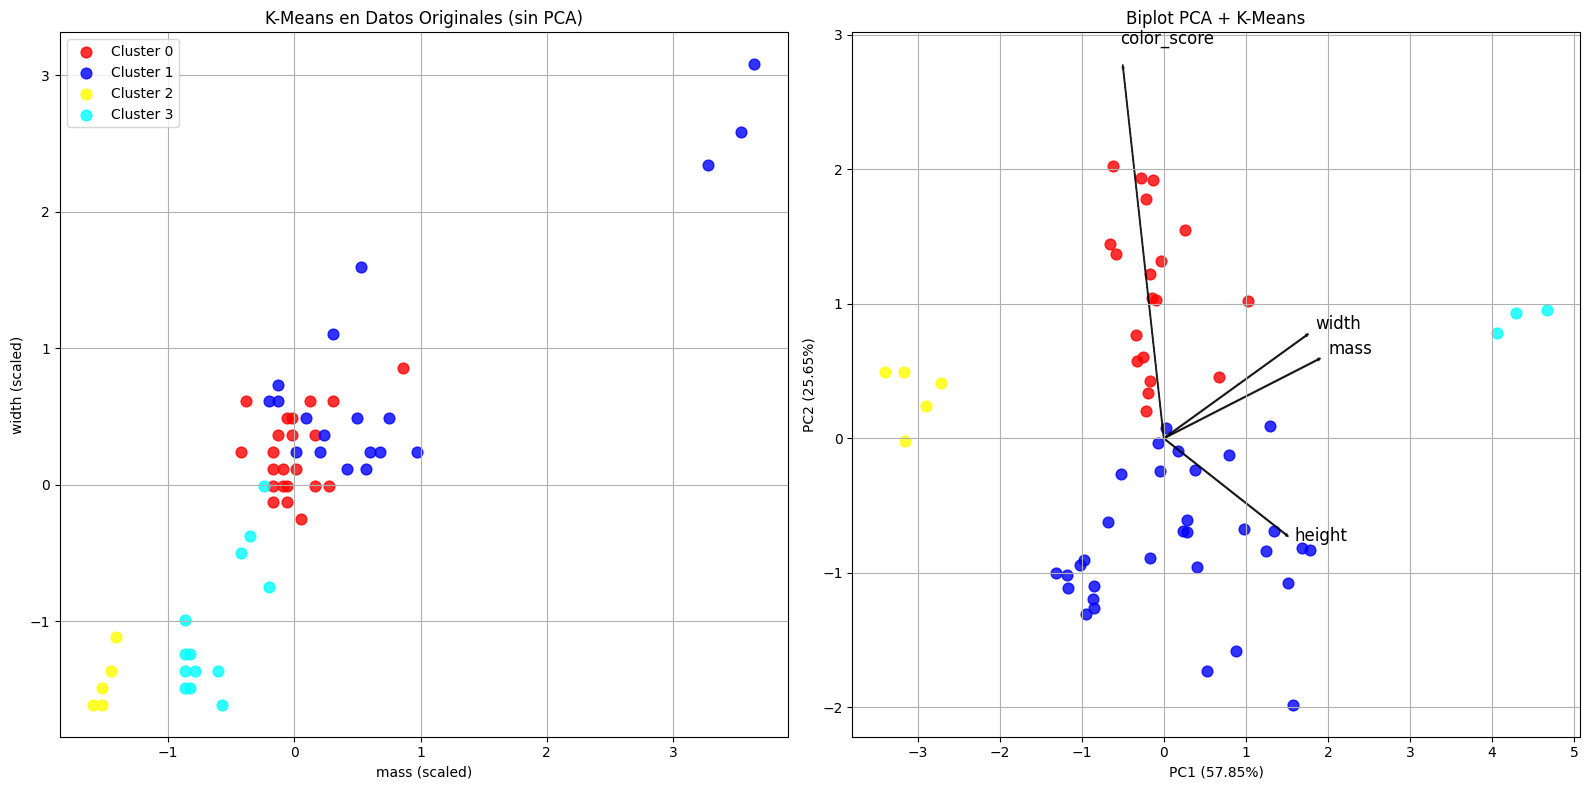

In [34]:
import matplotlib.pyplot as plt
import numpy as n
# --- PCA ---
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
loadings = pca.components_.T
variables = x.columns
# --- K-means sin PCA ---
kmeans_original = KMeans(n_clusters=4, random_state=42)
frutas["cluster_original"] = kmeans_original.fit_predict(x_scaled)
# --- K-means con PCA ---
kmeans_pca = KMeans(n_clusters=4, random_state=42)
frutas["cluster_pca"] = kmeans_pca.fit_predict(x_pca)
# --- Colores para clusters de la gráfica ---
palette = ['red', 'blue', 'yellow', 'cyan', 'orange', 'brown']
# --- SUBPLOTS PARA PONER GRAFICAS DE LADO A LADO ---
fig, axes = plt.subplots(1, 2, figsize=(16,8))
# SUBPLOT IZQUIERDO – Clústeres SIN PCA
ax = axes[0]
for c in sorted(frutas["cluster_original"].unique()):
    ax.scatter(
        x_scaled[frutas["cluster_original"] == c, 0],
        x_scaled[frutas["cluster_original"] == c, 1],
        s=60,
        alpha=0.8,
        color=palette[c],
        label=f"Cluster {c}"
    )
ax.set_title("K-Means en Datos Originales (sin PCA)")
ax.set_xlabel("mass (scaled)")
ax.set_ylabel("width (scaled)")
ax.grid(True)
ax.legend()
# SUBPLOT DERECHO – Biplot con PCA + Clústeres
ax = axes[1]
for c in sorted(frutas["cluster_pca"].unique()):
    ax.scatter(
        x_pca[frutas["cluster_pca"] == c, 0],
        x_pca[frutas["cluster_pca"] == c, 1],
        s=60,
        alpha=0.8,
        color=palette[c],
        label=f"Cluster {c}"
    )
# Flechas (loadings)
for i, var in enumerate(variables):
    ax.arrow(
        0,
        0,
        loadings[i,0] * 3,
        loadings[i,1] * 3,
        color='black',
        width=0.007,
        alpha=0.8
    )
    ax.text(
        loadings[i,0] * 3.2,
        loadings[i,1] * 3.2,
        var,
        color='black',
        fontsize=12
    )
ax.set_title("Biplot PCA + K-Means")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
ax.grid(True)
plt.tight_layout()
plt.show()

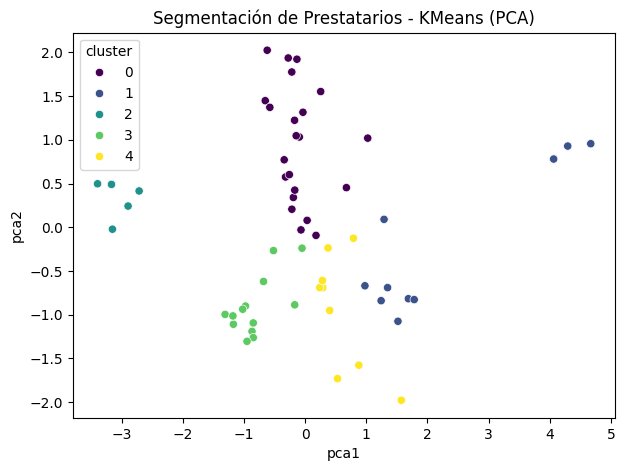

In [35]:
# --- Aplicamos K-Means con el k elegido (por ejemplo, 5) ---
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
frutas["cluster"] = clusters
# --- Visualización PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_scaled)
frutas["pca1"], frutas["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
sns.scatterplot(data=frutas, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.title("Segmentación de Prestatarios - KMeans (PCA)")
plt.show()